<h1> Experiment anti HOM probability against bandwith </h1>

In [42]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.antiHOM_vs_bandwith import run_antiHOM_vs_bandwith

<h2> Execute the experiment </h2>

Given an off-resonant scattering experiment, we test three different reference frequencies:
$$ \omega_{\rm ref} \in \{\omega_A, (\omega_A + \omega_q)/2, \omega_q\}$$

In [43]:
omega_A = 10*pi
Gamma = 5*pi

omega_q_tab = [omega_A - Gamma/2, omega_A - Gamma/3, omega_A - Gamma/4]
index_omega_q = 2
omega_q = omega_q_tab[index_omega_q - 1]

omega_ref_values = [omega_A, 
                    (omega_A + omega_q)/2, 
                    omega_q]

nb_pts_bandwith = 30
lbda_tab_largest = np.linspace(pi, omega_A, nb_pts_bandwith)

lbda_tab_values = [lbda_tab_largest,
                   lbda_tab_largest[lbda_tab_largest < omega_ref_values[1]],
                   lbda_tab_largest[lbda_tab_largest < omega_ref_values[2]]]

In [ ]:
for i in range(len(omega_ref_values)):
    index_experiment = i+1
    print("Running central frequency ", index_experiment, " out of ", len(omega_ref_values))
    lbda_tab, antiHOM_proba_tab = run_antiHOM_vs_bandwith(omega_ref_values[i], lbda_tab_values[i], index_experiment, index_omega_q 
                                                          store_results=True, progress=True)


Running central frequency  1  out of  3


100%|██████████| 30/30 [23:03<00:00, 46.10s/it] 


Running central frequency  2  out of  3


100%|██████████| 25/25 [14:51<00:00, 35.66s/it]


Running central frequency  3  out of  3


100%|██████████| 21/21 [09:22<00:00, 26.76s/it]


<h2> Plot the results </h2>

Recover the data

In [5]:
antiHOM_proba = []
lbda_tab = []

for i in range(3):
    index_experiment = i+1
    data_file = f"../results/csv_files/antiHOM_vs_bandwith_{index_experiment}.csv"
    df = pd.read_csv(data_file)
    antiHOM_proba.append(df['antiHOM_proba_tab'].to_numpy())
    lbda_tab.append(df['lbda_tab'].to_numpy())


Compute the theoretical value 

In [ ]:
index_omega_q = 1

if index_omega_q == 1:
    Gamma = 5*pi
    Delta_q = 0.05*pi
    non_monochr_ratio = Gamma / (2*Delta_q)
    theoretical_val = 1/(np.sqrt(pi) * non_monochr_ratio)
else:
    R_theory_physical = 1 / (1 + ((omega_q_tab[index_omega_q-1] - omega_A)/ (Gamma/2))**2)
    theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

print(theoretical_val)

0.011283791670955126


Generate the figure

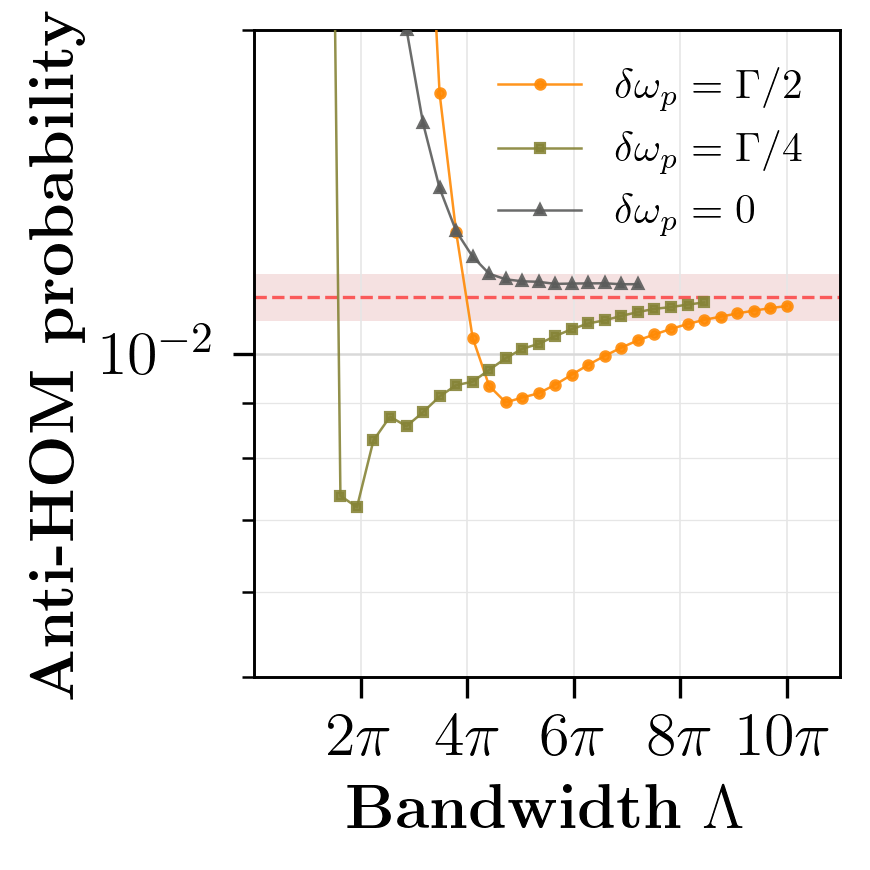

In [ ]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Palette sobre + markers distincts
colors  = ["#ff8a05", "#868437", "#5b5c5b"]
markers = ["o", "s", "^"]   # cercle, carré, triangle
labels  = [r'$ \delta \omega_q = \Gamma / 2$', r'$\delta \omega_q = \Gamma/4$', r'$\delta \omega_q = 0$']

# Scatter plots
for i in range(3):
    ax.plot(
        lbda_tab[i],
        antiHOM_proba[i],
        marker=markers[i],
        color=colors[i],
        markersize=2,
        linewidth=0.6,
        alpha=0.9,
        zorder=3,
        label=labels[i]
    )

#theoretical value
ax.hlines(theoretical_val, 0, 1.1*10*pi,color='red', alpha=0.6, linewidth=0.8, linestyle='--')
y_low  = 0.95 * theoretical_val
y_high = 1.05 * theoretical_val
ax.fill_between(np.linspace(0, 1.1*10*pi, 100),y_low,y_high,color='#b00b0b',alpha=0.12,linewidth=0, zorder=1)


# Axes scaling and limits
ax.set_xlim(0, 1.1*10*pi)
ax.set_xticks([2*pi, 4*pi, 6*pi, 8*pi, 10*pi])
ax.set_xticklabels([r"$2\pi$", r"$4\pi$", r"$6\pi$", r"$8\pi$", r"$10\pi$"])

ax.set_yscale('log')
ax.set_ylim(5e-3, 2e-2)

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=15)
ax.set_ylabel(r'\textbf{Anti-HOM probability}', fontsize=15)

# --- Log scale ticks ---
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(1,2,3,4,5,6,7,8,9)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# --- Grid: fine horizontal grid on log scale ---
ax.grid(which='major', axis='y', color='0.85', linestyle='-', linewidth=0.6)
ax.grid(which='minor', axis='y', color='0.9', linestyle='-', linewidth=0.3)
ax.grid(which='major', axis='x', color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
ax.legend(prop={'size': 10}, frameon=False, loc="best")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

for item in ax.get_xticklabels() + ax.get_yticklabels():
    item.set_fontsize(15)

plt.tight_layout()
plt.show()